# Predicting Antibacterial Activity Against E. coli Using Molecular Descriptors

### Priscilla Vaskez · Trinity Ho · Yasemin Sucu · Dongwan Kim

## Objective

Predict antibacterial activity against *Escherichia coli* using compound screening data from the Community for Open Antimicrobial Drug Discovery (CO-ADD) database. Compounds are represented by molecular descriptors and structural fingerprints derived from SMILES, combined with assay-derived measurements such as DMAX_AVE. After exploratory analysis showed that direct regression of inhibition values was unreliable on this dataset, the task is framed as an assay-aware classification problem: identifying compounds in the top 10% of INHIB_AVE. Multiple machine-learning approaches, including logistic regression, ElasticNet-regularized logistic regression, support vector machines, an artificial neural network, and unsupervised clustering are compared to determine which best captures inhibition patterns.

## Introduction 

Antibiotic resistance has become one of the most urgent challenges in modern medicine, identified by the World Health Organization as a top-ten global public health threat and projected to cause up to ten million deaths annually by 2050 if current trends continue (O'Neill, 2016; Murray et al., 2022). Gram-negative pathogens such as *Escherichia coli* are especially challenging because their double-membrane structure restricts antibiotic entry, resistance has spread rapidly across clinical isolates, and *E. coli* alone drives the majority of community-acquired urinary tract infections and a substantial share of bloodstream infections worldwide. Despite the clinical urgency, antibiotic discovery remains slow and inefficient, with phenotypic screening of millions of compounds typically yielding very low hit rates and requiring substantial experimental effort to identify promising candidates (Tommasi et al., 2015). *In silico* pre-filtering through quantitative structure-activity relationship (QSAR) modeling has emerged as a way to triage candidates before experimental validation (Cherkasov et al., 2014).

In this project, we developed a machine learning pipeline that predicts *E. coli* growth inhibition (INHIB_AVE) using data from the Community for Open Antimicrobial Drug Discovery (CO-ADD), a publicly available repository designed to support antibiotic discovery through large-scale phenotypic screening (Blaskovich et al., 2015). Our feature representation combines nine interpretable RDKit descriptors with 1,024-bit Morgan circular fingerprints, which are widely used in cheminformatics for encoding local structural environments in molecules (Rogers & Hahn, 2010). For the strongest classification model we extend this with MACCS keys and Tanimoto similarity features to capture broader structural relationships between compounds. After exploratory analysis showed that the inhibition distribution was noisy and weakly separable for direct regression, we frame the task as assay-aware classification: predicting compounds in the top 10% of INHIB_AVE from chemical structure together with DMAX_AVE, a dose-response readout obtained from an independent wet-lab assay rather than the same measurement procedure. This framing reflects a realistic compound-prioritization scenario in which partial assay data is leveraged for downstream extrapolation, rather than a structure-only setting. We compare regression baselines, four supervised classifiers (logistic regression, ElasticNet-regularized logistic regression, support vector machines, and an artificial neural network), and unsupervised clustering methods to determine which framework best captures inhibition patterns in this dataset.


# Basic Data Preview

Read CO-ADD CSV files with pandas and preview the first rows using `head()`.

CO-ADD provides two CSV files because they serve different purposes:
- `InhibitionData` contains single-concentration inhibition results (good for quick screening).
- `DoseResponseData` contains multi-concentration dose-response results (better for detailed potency analysis).

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pylab
import scipy.stats as stats
import statsmodels.api as sm
import tensorflow as tf
import umap
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, QED, rdMolDescriptors, rdFingerprintGenerator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.cluster import KMeans

---
This sets the folder and file paths for the two CO-ADD CSV files.
- `DATA_DIR` points to the folder containing the data.
- `INHIB_PATH` and `DOSE_PATH` build the full path to each CSV file using `Path` / operator.

In [2]:
DATA_DIR = Path("CO-ADD_r03.02-2020_CSV")
INHIB_PATH = DATA_DIR / "CO-ADD_InhibitionData_r03_01-02-2020_CSV.csv"
DOSE_PATH = DATA_DIR / "CO-ADD_DoseResponseData_r03_01-02-2020_CSV.csv"

---

## Open Inhibition data CSV file

In [3]:
# There are two CSV files in the CO-ADD folder.
# For now, we will open the InhibitionData file.

df = pd.read_csv(INHIB_PATH, low_memory=False)
print(df.head())

   Unnamed: 0        COADD_ID  COMPOUND_CODE COMPOUND_NAME     PROJECT_ID  \
0           0  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
1           1  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
2           2  CO-ADD:0227954  A0879/0041231           NaN  CO-ADD:PC0244   
3           3  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   
4           4  CO-ADD:0227808  A0856/0040122           NaN  CO-ADD:PC0244   

                          LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  Russian Academy of Science (Russia)   GN_046         Escherichia coli   
1  Russian Academy of Science (Russia)   GN_049         Escherichia coli   
2  Russian Academy of Science (Russia)   GP_020    Staphylococcus aureus   
3  Russian Academy of Science (Russia)   FG_001         Candida albicans   
4  Russian Academy of Science (Russia)   FG_002  Cryptococcus neoformans   

             STRAIN  NASSAYS  INHIB_AVE  INHIB_STD      CONC  \
0      lpxC; MB4

---
## Open the other CO-ADD file (DoseResponseData)

In [4]:
# Open the other CO-ADD file (DoseResponseData)
df2 = pd.read_csv(DOSE_PATH, low_memory=False)
print(df2.head())

   Unnamed: 0        COADD_ID COMPOUND_CODE COMPOUND_NAME  \
0           0  CO-ADD:0136135    0367428:01           NaN   
1           1  CO-ADD:0136135    0367428:01           NaN   
2           2  CO-ADD:0136135    0367428:01           NaN   
3           3  CO-ADD:0136135    0367428:01           NaN   
4           4  CO-ADD:0136135    0367428:01           NaN   

                                   SMILES     PROJECT_ID  \
0  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
1  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
2  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
3  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   
4  [H]N1C(N([H])C(OC)C(C(OC)=O)(F)C1=O)=O  CO-ADD:PL0011   

                      LIBRARY_NAME ASSAY_ID                 ORGANISM  \
0  NIH/NCI (USA) - Diversity Set V   MA_007             Homo sapiens   
1  NIH/NCI (USA) - Diversity Set V   GP_020    Staphylococcus aureus   
2  NIH/NCI (USA) - Diversity Set V   GN_042   Pseudomona

---
The below cell reads the two CO-ADD CSV files into pandas DataFrames and prints basic information about them.
- `shape` shows the number of rows and columns in each file.
- `columns.tolist()` lists the column names so you can see what data fields are available.
This helps verify the files loaded correctly and shows what information each dataset contains.

In [5]:
df_inhib = pd.read_csv(INHIB_PATH, low_memory=False)
df_dose = pd.read_csv(DOSE_PATH, low_memory=False)

print("InhibitionData shape:", df_inhib.shape)
print("DoseResponseData shape:", df_dose.shape)

print("\nInhibitionData columns:")
print(df_inhib.columns.tolist())

print("\nDoseResponseData columns:")
print(df_dose.columns.tolist())

InhibitionData shape: (802918, 14)
DoseResponseData shape: (42209, 15)

InhibitionData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES']

DoseResponseData columns:
['Unnamed: 0', 'COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'SMILES', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


In [6]:
ORGANISM_COL = "ORGANISM"
ECOLI_NAME = "Escherichia coli"
EXACT_KEYS = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Find E. coli rows in inhibition data
mask_inhib = df_inhib[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

# Find E. coli rows in dose-response data
mask_dose = df_dose[ORGANISM_COL].astype(str).str.contains(ECOLI_NAME, na=False)

ecoli_inhib = df_inhib.loc[mask_inhib].copy()
ecoli_dose = df_dose.loc[mask_dose].copy()

# Diagnostic counts: compound-level overlap and exact experiment-level overlap.
overlap_ids = set(ecoli_inhib["COADD_ID"]).intersection(ecoli_dose["COADD_ID"])
inhib_exact_keys = set(map(tuple, ecoli_inhib[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
dose_exact_keys = set(map(tuple, ecoli_dose[EXACT_KEYS].dropna().drop_duplicates().to_numpy()))
overlap_exact_keys = inhib_exact_keys.intersection(dose_exact_keys)

print(f"E. coli inhibition rows: {len(ecoli_inhib):,}")
print(f"E. coli dose-response rows: {len(ecoli_dose):,}")
print(f"Overlapping COADD_ID values: {len(overlap_ids):,}")
print(f"Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): {len(overlap_exact_keys):,}")
print(f"Unique E. coli inhibition strains: {ecoli_inhib['STRAIN'].nunique()}")
print(f"Unique E. coli dose-response strains: {ecoli_dose['STRAIN'].nunique()}")

E. coli inhibition rows: 237,752
E. coli dose-response rows: 4,711
Overlapping COADD_ID values: 4,174
Overlapping exact keys (COADD_ID, STRAIN, ASSAY_ID): 4,268
Unique E. coli inhibition strains: 3
Unique E. coli dose-response strains: 4


---
We will use all the strains of E. coli for this project. This means we are not excluding any specific E. coli variant from the initial analysis, so the data will reflect the full diversity of E. coli strains present in the CO-ADD datasets. This helps us get a broad view of how E. coli responds overall before we decide whether to compare individual strains later.

---
## Create a simple merged E. coli DataFrame

We match the two CSV files using `COADD_ID`, `STRAIN`, and `ASSAY_ID` so the inhibition and dose-response values come from the same E. coli experiment. This gives us 4268 exact-matched rows across 4174 unique compounds while keeping the existing columns and only adding the non-overlapping columns from the dose-response file.


In [7]:
# Use COADD_ID + STRAIN + ASSAY_ID so the rows refer to the same exact experiment.
exact_keys = ["COADD_ID", "STRAIN", "ASSAY_ID"]

# Remove rows missing the merge keys or SMILES, and keep one row per exact match key.
def keep_exact_rows(df):
    return (
        df
        .dropna(subset=exact_keys + ["SMILES"])
        .drop_duplicates(subset=exact_keys)
        .reset_index(drop=True)
    )

ecoli_inhib_exact = keep_exact_rows(ecoli_inhib)
ecoli_dose_exact = keep_exact_rows(ecoli_dose)

# Find the columns that appear only in the dose-response table.
# The exact match keys are excluded because they are already used for the merge.
dose_only_cols = [
    col for col in ecoli_dose_exact.columns
    if col not in ecoli_inhib_exact.columns and col not in exact_keys
]

# Merge the two cleaned tables into one exact-match DataFrame.
# Keep all columns from the inhibition table and add only new columns from the dose-response table.
ecoli_merged_df = pd.merge(
    ecoli_inhib_exact,
    ecoli_dose_exact[exact_keys + dose_only_cols],
    on=exact_keys,
    how="inner"
)
ecoli_merged_df = ecoli_merged_df.drop(columns=["Unnamed: 0"])

print("Merged E. coli DataFrame shape:", ecoli_merged_df.shape)
print("Unique COADD_ID values:", ecoli_merged_df["COADD_ID"].nunique())
print("Added columns from dose-response file:\n", dose_only_cols)
print(ecoli_merged_df.columns.tolist())

ecoli_merged_df.head()

Merged E. coli DataFrame shape: (4268, 17)
Unique COADD_ID values: 4174
Added columns from dose-response file:
 ['DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']
['COADD_ID', 'COMPOUND_CODE', 'COMPOUND_NAME', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE']


,COADD_ID,COMPOUND_CODE,COMPOUND_NAME,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,CONC,SMILES,DRVAL_TYPE,DRVAL_MEDIAN,DRVAL_UNIT,DMAX_AVE
0,CO-ADD:0227615,A0877/0041139,NaN,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,32 ug/mL,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,MIC,>32,ug/mL,6.85
1,CO-ADD:0231316,A0969/0045283,NaN,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,32 ug/mL,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,MIC,>32,ug/mL,10.35
2,CO-ADD:0166443,A0501/0023282,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,80 ug/mL,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,MIC,>32,uM,9.15
3,CO-ADD:0166253,A0494/0022904,NaN,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,80 ug/mL,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,MIC,>32,uM,1.65
4,CO-ADD:0215273,A0528/0024455,NaN,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,32 ug/mL,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,MIC,>32,ug/mL,-13.30


In [8]:
ecoli_merged_df.isna().sum().sort_values(ascending=False)

# Might need to drop some columns before moving on 
# Also need to convert to same units for some columns (e.g. MIC values) before doing any analysis.

COMPOUND_NAME    4177
COADD_ID            0
INHIB_AVE           0
DRVAL_UNIT          0
DRVAL_MEDIAN        0
DRVAL_TYPE          0
SMILES              0
CONC                0
INHIB_STD           0
NASSAYS             0
COMPOUND_CODE       0
STRAIN              0
ORGANISM            0
ASSAY_ID            0
LIBRARY_NAME        0
PROJECT_ID          0
DMAX_AVE            0
dtype: int64

---
`COMPOUND_NAME` has many missing values and is not needed for modeling, so we drop it before feature engineering.

In [9]:
ecoli_merged_df = ecoli_merged_df.drop(columns=["COMPOUND_NAME"])

print("Shape after dropping COMPOUND_NAME:", ecoli_merged_df.shape)

Shape after dropping COMPOUND_NAME: (4268, 16)


---
`DRVAL_MEDIAN` is a dose-response measurement column from the CO-ADD `DoseResponseData` file.
`DRVAL_MEDIAN` contains MIC values with operators like `>`, `<`, `<=`, and `>=`, so we split it into an operator column and a numeric value column.

In [10]:
dose_response_raw = ecoli_merged_df["DRVAL_MEDIAN"].astype(str).str.strip()

ecoli_merged_df["MIC_OPERATOR"] = dose_response_raw.str.extract(r"^(<=|>=|<|>)", expand=False).fillna("=")
ecoli_merged_df["MIC_VALUE"] = pd.to_numeric(
    dose_response_raw.str.replace(r"^(<=|>=|<|>)\s*", "", regex=True),
    errors="coerce"
)

print(ecoli_merged_df[["DRVAL_MEDIAN", "MIC_OPERATOR", "MIC_VALUE"]].head())

  DRVAL_MEDIAN MIC_OPERATOR  MIC_VALUE
0          >32            >       32.0
1          >32            >       32.0
2          >32            >       32.0
3          >32            >       32.0
4          >32            >       32.0


---
`DRVAL_UNIT` includes mixed MIC units (`uM` and `ug/mL`), so we first check the unit distribution before any conversion.

In [11]:
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MIC_VALUE"]].head())

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT  MIC_VALUE
0          >32      ug/mL       32.0
1          >32      ug/mL       32.0
2          >32         uM       32.0
3          >32         uM       32.0
4          >32      ug/mL       32.0


---
We extract RDKit descriptors from `SMILES` and append them to `ecoli_merged_df`. This follows the HW4 feature extraction structure, adapted for this dataset.

In [12]:
# Adapted from the HW4 RDKit feature extraction example provided in class.

DESCRIPTOR_COLUMNS = [
    "MW",
    "logP",
    "TPSA",
    "HBD",
    "HBA",
    "RotBonds",
    "Rings",
    "ArRings",
    "QED",
]

def preprocess_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {col: None for col in DESCRIPTOR_COLUMNS}

    return {
        "MW": Descriptors.MolWt(mol),
        "logP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "ArRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "QED": QED.qed(mol),
    }

descriptor_list = ecoli_merged_df["SMILES"].apply(preprocess_molecule).tolist()
descriptor_df = pd.DataFrame(descriptor_list)

ecoli_merged_df = pd.concat(
    [ecoli_merged_df.reset_index(drop=True), descriptor_df.reset_index(drop=True)],
    axis=1,
)

print("Descriptor columns added:", DESCRIPTOR_COLUMNS)
print("Rows with descriptor failure:", int(descriptor_df["MW"].isna().sum()))
print("Updated shape:", ecoli_merged_df.shape)

ecoli_merged_df[["SMILES"] + DESCRIPTOR_COLUMNS].head()

Descriptor columns added: ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']
Rows with descriptor failure: 0
Updated shape: (4268, 27)


,SMILES,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED
0,N(=C\c1cccc(F)c1O)/c2cc(C)c(cc2O)C,259.280,3.60434,52.82,2,3,2,2,2,0.809417
1,C(=O)(Oc(cc1)ccc1\C=N\c(cc2)ccc2Br)\C=C\C(=O)O...,632.308,7.78000,77.32,0,6,8,4,4,0.086099
2,C(=O)(N\N=C\c1cc(Br)ccc1O)C(=O)NC(C)c2ccccc2,390.237,2.48220,90.79,3,4,4,2,2,0.425706
3,C(CCc1ccccc1)(=O)Nc(cc2)ccc2I,351.187,3.86250,29.10,1,1,4,2,2,0.833075
4,N1(c2cccc(c2)[N+](=O)[O-])C(=O)C(C3C1=O)C(c4cc...,424.456,4.83780,80.52,0,4,4,5,3,0.259822


---
Now we use `MW` to convert MIC values in `DRVAL_UNIT == "ug/mL"` into `uM`, then keep a single unified MIC column for modeling.

In [13]:
# Convert MIC to a single numeric unit (uM).
# Unit conversion rationale:
#  MW is in g/mol, and MIC_VALUE for this branch is in ug/mL.
#  1 ug/mL = 1 mg/L, so (mg/L) / (g/mol) gives mmol/L (mM).
#  Multiplying by 1000 converts mM to uM.
# Therefore: uM = (ug/mL) * 1000 / MW.
ecoli_merged_df["MIC_VALUE_uM"] = np.where(
    ecoli_merged_df["DRVAL_UNIT"] == "uM",
    ecoli_merged_df["MIC_VALUE"],
    np.where(
        ecoli_merged_df["DRVAL_UNIT"] == "ug/mL",
        ecoli_merged_df["MIC_VALUE"] * 1000 / ecoli_merged_df["MW"],
        np.nan,
    ),
)

# Drop only the intermediate MIC_VALUE column; keep all other columns for later machine learning analysis.
# Remove MIC_VALUE because MIC_VALUE_uM is the converted unified MIC column and keeping both would be redundant.
ecoli_merged_df = ecoli_merged_df.drop(columns=["MIC_VALUE"])

# Quick checks after conversion.
print(ecoli_merged_df["DRVAL_UNIT"].value_counts(dropna=False))
print(ecoli_merged_df[["DRVAL_MEDIAN", "DRVAL_UNIT", "MW", "MIC_VALUE_uM"]].head())
print("Missing MIC_VALUE_uM:", int(ecoli_merged_df["MIC_VALUE_uM"].isna().sum()))

DRVAL_UNIT
ug/mL    3775
uM        493
Name: count, dtype: int64
  DRVAL_MEDIAN DRVAL_UNIT       MW  MIC_VALUE_uM
0          >32      ug/mL  259.280    123.418698
1          >32      ug/mL  632.308     50.608248
2          >32         uM  390.237     32.000000
3          >32         uM  351.187     32.000000
4          >32      ug/mL  424.456     75.390618
Missing MIC_VALUE_uM: 0


---
We save the current `ecoli_merged_df` as a master CSV file so it can be reused later for modeling and analysis.

In [14]:
OUTPUT_CSV = "ecoli_merged_master_4268.csv"

ecoli_merged_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Shape:", ecoli_merged_df.shape)
print("Feature columns:", ecoli_merged_df.columns.tolist())
print("Missing values by column:")
print(ecoli_merged_df.isna().sum())

ecoli_merged_df.head(8)

Saved: ecoli_merged_master_4268.csv
Shape: (4268, 27)
Feature columns: ['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM']
Missing values by column:
COADD_ID         0
COMPOUND_CODE    0
PROJECT_ID       0
LIBRARY_NAME     0
ASSAY_ID         0
ORGANISM         0
STRAIN           0
NASSAYS          0
INHIB_AVE        0
INHIB_STD        0
CONC             0
SMILES           0
DRVAL_TYPE       0
DRVAL_MEDIAN     0
DRVAL_UNIT       0
DMAX_AVE         0
MIC_OPERATOR     0
MW               0
logP             0
TPSA             0
HBD              0
HBA              0
RotBonds         0
Rings            0
ArRings          0
QED              0
MIC_VALUE_uM     0
dtype: int64


,COADD_ID,COMPOUND_CODE,PROJECT_ID,LIBRARY_NAME,ASSAY_ID,ORGANISM,STRAIN,NASSAYS,INHIB_AVE,INHIB_STD,...,MW,logP,TPSA,HBD,HBA,RotBonds,Rings,ArRings,QED,MIC_VALUE_uM
0,CO-ADD:0227615,A0877/0041139,CO-ADD:PC0244,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,16.13,0.52,...,259.280,3.60434,52.82,2,3,2,2,2,0.809417,123.418698
1,CO-ADD:0231316,A0969/0045283,CO-ADD:PC0249,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,6.84,3.57,...,632.308,7.78000,77.32,0,6,8,4,4,0.086099,50.608248
2,CO-ADD:0166443,A0501/0023282,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,15.32,1.90,...,390.237,2.48220,90.79,3,4,4,2,2,0.425706,32.000000
3,CO-ADD:0166253,A0494/0022904,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,4.33,4.05,...,351.187,3.86250,29.10,1,1,4,2,2,0.833075,32.000000
4,CO-ADD:0215273,A0528/0024455,CO-ADD:PC0221,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,2.11,6.61,...,424.456,4.83780,80.52,0,4,4,5,3,0.259822,75.390618
5,CO-ADD:0166394,A0499/0023186,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.33,1.35,...,447.403,3.50320,137.20,1,8,7,3,3,0.192320,32.000000
6,CO-ADD:0166623,A0507/0023549,CO-ADD:PC0217,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,3.83,0.09,...,425.226,2.56760,82.95,3,5,6,2,2,0.377659,32.000000
7,CO-ADD:0218495,A0613/0028414,CO-ADD:PC0228,Russian Academy of Science (Russia),GN_001,Escherichia coli,ATCC 25922,2,33.58,3.38,...,482.196,4.58110,61.69,2,3,7,1,1,0.339824,66.363056


---
Load the saved master CSV, keep numeric columns for machine learning, split into `X` and `y`, then apply `StandardScaler`.

In [15]:
# We need `master_df`` for additional feature engineering after trying some models if needed.
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

# Define a function that takes a SMILES string and returns a Morgan fingerprint

def get_morgan_fingerprint(smiles):
    
    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    # If the molecule is invalid, return a list of 1024 zeros
    if mol is None:
        return [0] * 1024
    
    # Compute the Morgan fingerprint with radius=2 and nBits=1024
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    fingerprint = generator.GetFingerprint(mol)
    
    # Convert the fingerprint to a list and return it
    return list(fingerprint)

# Apply the function to every SMILES string in master_df
morgan_list = master_df['SMILES'].apply(get_morgan_fingerprint).tolist()

# Convert the results into a dataframe with 1024 columns
morgan_df = pd.DataFrame(morgan_list, columns=[f'morgan_{i}' for i in range(1024)])

# Join the fingerprint dataframe back to master_df
master_df = pd.concat([master_df.reset_index(drop=True), morgan_df.reset_index(drop=True)], axis=1)

# Check the new shape of master_df
print(master_df.shape)

(4268, 1051)


In [16]:
# Define numeric feature columns explicitly for clarity.
numeric_feature_cols = master_df.select_dtypes(include=["number"]).columns.tolist()
print("All numeric columns:", numeric_feature_cols)

# Keep only numeric columns for machine learning.
numeric_df = master_df[numeric_feature_cols].copy()

X = numeric_df.drop(columns=["INHIB_AVE"])
y = numeric_df["INHIB_AVE"]

# Making the binary lables for stratification
y_binary = (y > y.quantile(0.7)).astype(int)

# Adding the stratify in order to make sure both training and test sets have the same ratio of inactive and active compounds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28, stratify=y_binary)

# Sanity check to verify stratify worked correctly
print("Training class balance:", y_binary[X_train.index].value_counts())
print("Test class balance:", y_binary[X_test.index].value_counts())

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("numeric_df shape:", numeric_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Numeric feature columns:", X.columns.tolist())

All numeric columns: ['NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_52', 'morgan_53', 'morgan_54', 'morgan_55', 'morgan_56', 'morgan_57', 'morgan_58', 'morgan_59', 'morgan_60', 'morgan_61', 'morgan_62', 'morgan_63', 'morgan_64', 'mo

In [17]:
# Checking the current shape and columns of master_df before feature engineering
print(master_df.shape)
print(master_df.columns.tolist())

(4268, 1051)
['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_5

# EDA Distribution of INHIB_AVE

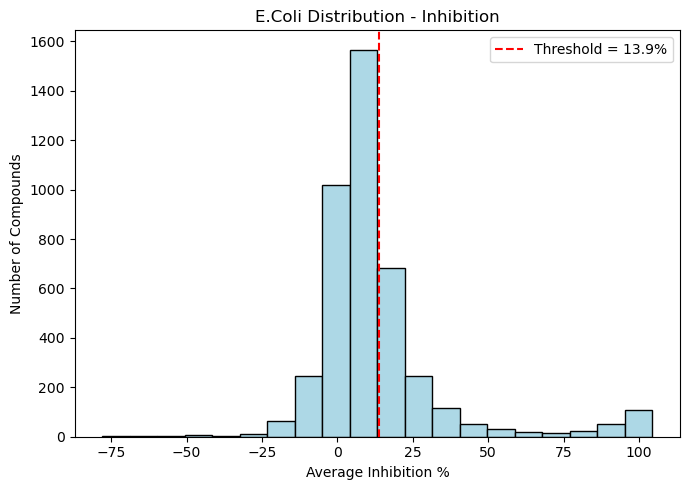

In [18]:
# Calculating the 70th percentile of INHIB_AVE to use as our cutoff
# Compounds above this value are active, below are inactive
threshold = master_df['INHIB_AVE'].quantile(0.7)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting the distribution of INHIB_AVE 
ax.hist(master_df['INHIB_AVE'], bins=20, edgecolor='black', color='lightblue')

# Adding a vertical line to show where the active/inactive cutoff is
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.1f}%')

# Adding the title and labels
ax.set_title('E.Coli Distribution - Inhibition')
ax.set_xlabel('Average Inhibition %')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

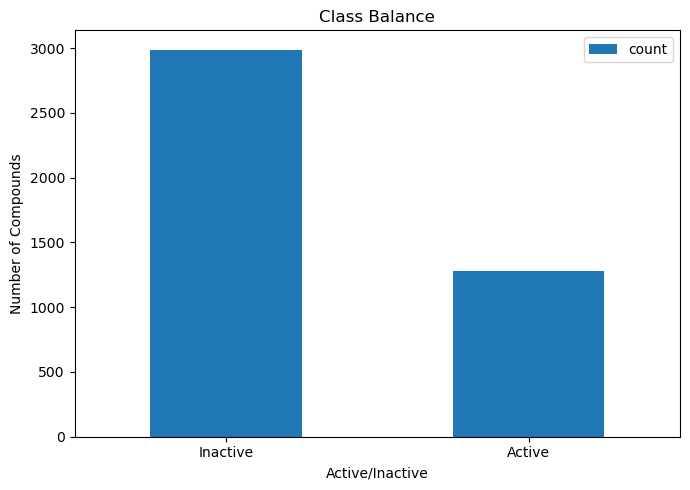

In [19]:
# Creating binary labels - 1 if compound is active (above threshold), 0 if inactive
ydummy_train = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Making the figure
fig, ax = plt.subplots(figsize=(7,5))

# Plotting how many compounds fall into each class
ydummy_train.value_counts().plot(kind='bar', ax=ax)

# Labeling the bars and add title
ax.set_xticklabels(['Inactive', 'Active'], rotation=0)
ax.set_title('Class Balance')
ax.set_xlabel('Active/Inactive')
ax.set_ylabel('Number of Compounds')
ax.legend()

plt.tight_layout()
plt.show()

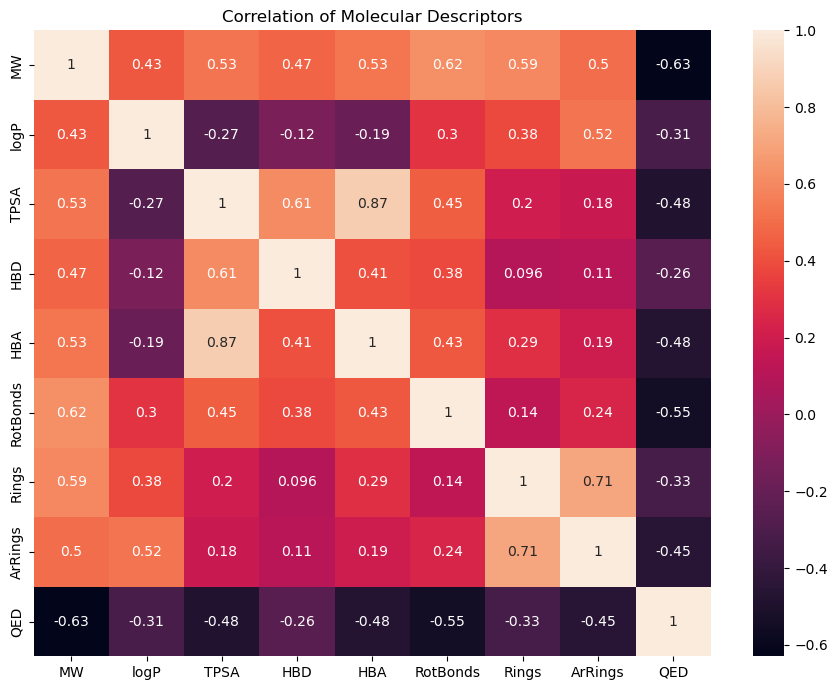

In [20]:
# Listing of the 9 molecular descriptors we computed from SMILES
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Making the figure
fig, ax = plt.subplots(figsize=(9,7))


# Plotting the correlation between all 9 descriptors
sns.heatmap(master_df[DESCRIPTOR_COLUMNS].corr(), annot=True, ax=ax)

# Adfding title
ax.set_title('Correlation of Molecular Descriptors')

plt.tight_layout()
plt.show()

----------------------------
## Simple Logistic Regression Model

A Gaussian Mixture Model (GMM) was applied to the distribution of INHIB_AVE to identify potential latent subpopulations in antibacterial activity. The left panel shows the fitted mixture model overlaid on the empirical distribution, where two Gaussian components capture low and high inhibition groups, and a data-driven cutoff is defined at the midpoint between component means. The right panel shows the corresponding cluster assignments for each observation, illustrating how samples are probabilistically separated into two biologically meaningful groups. This approach provides a more interpretable and data-driven alternative to an arbitrary median split for defining inhibition classes.

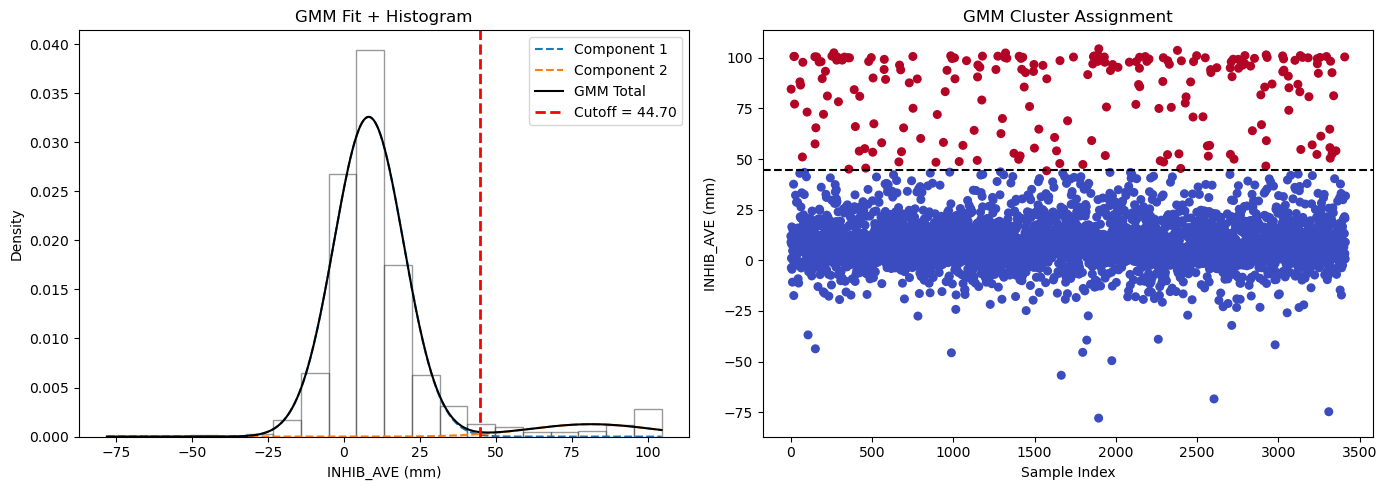

In [21]:
data = y_train.values.reshape(-1, 1)

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Cutoff
means = gmm.means_.flatten()
threshold = np.mean(means)

# Smooth density curve
x = np.linspace(data.min(), data.max(), 500).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

responsibilities = gmm.predict_proba(x)
pdf_individual = responsibilities * pdf[:, np.newaxis]

# Cluster labels for each sample
labels = gmm.predict(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + GMM + cutoff
axes[0].hist(data, bins=20, density=True, alpha=0.4,
             color='white', edgecolor='black')

axes[0].plot(x, pdf_individual[:, 0], '--', label='Component 1')
axes[0].plot(x, pdf_individual[:, 1], '--', label='Component 2')
axes[0].plot(x, pdf, 'k-', label='GMM Total')

axes[0].axvline(threshold, color='red', linestyle='--',
                linewidth=2, label=f'Cutoff = {threshold:.2f}')

axes[0].set_title("GMM Fit + Histogram")
axes[0].set_xlabel("INHIB_AVE (mm)")
axes[0].set_ylabel("Density")
axes[0].legend()


# GMM clustering view

axes[1].scatter(range(len(data)), data, c=labels, cmap='coolwarm', s=30)

axes[1].axhline(threshold, color='black', linestyle='--')

axes[1].set_title("GMM Cluster Assignment")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("INHIB_AVE (mm)")

plt.tight_layout()
plt.show()

In [22]:
print("Means:", gmm.means_.flatten())
print("Variances:", gmm.covariances_.flatten())
print("Weights:", gmm.weights_.flatten())

Means: [ 8.1275686  81.26338313]
Variances: [131.00245564 421.11691684]
Weights: [0.93502847 0.06497153]


The Gaussian Mixture Model does not support a biologically meaningful bimodal structure in INHIB_AVE. One dominant distribution accounts for the majority of observations, while a second small component corresponds to extreme high-value outliers. Therefore, a data-driven threshold based on distribution quantiles is more appropriate than mixture-based clustering. A 70th percentile cutoff was selected to define high antibacterial activity, ensuring a balanced yet biologically meaningful classification of the strongest-performing compounds. This choice avoids sensitivity to extreme outliers observed in the distribution and provides sufficient class representation for stable model estimation.

In [23]:
threshold = y_train.quantile(0.7)

ydummy_train = (y_train > threshold).astype(int)
ydummy_test = (y_test > threshold).astype(int)

print("Threshold:", threshold)
print(ydummy_train.value_counts())

Threshold: 13.92
INHIB_AVE
0    2391
1    1023
Name: count, dtype: int64


0 = low / moderate inhibition (bottom 70%)
1 = high inhibition (top 30%)

In [24]:
X_train_glm = sm.add_constant(X_train_scaled)

glm_model = sm.GLM(ydummy_train, X_train_glm, family=sm.families.Binomial())
glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                         1037
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -801.42
Date:                Tue, 05 May 2026   Deviance:                       1602.8
Time:                        01:29:21   Pearson chi2:                 1.80e+04
No. Iterations:                    24   Pseudo R-squ. (CS):             0.5284
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.0054    252.243     -0.016   

We now make prediction on test dataset

Accuracy: 0.6791569086651054
               Feature      Coef  Odds Ratio
morgan_939  morgan_939  3.408989   30.234673
DMAX_AVE      DMAX_AVE  2.577169   13.159827
morgan_659  morgan_659  1.922687    6.839313
ArRings        ArRings  1.437385    4.209673
morgan_231  morgan_231  1.335015    3.800054
...                ...       ...         ...
morgan_561  morgan_561 -1.995253    0.135979
morgan_838  morgan_838 -2.235978    0.106888
morgan_312  morgan_312 -2.257393    0.104623
morgan_685  morgan_685 -2.305338    0.099725
morgan_373  morgan_373 -2.982933    0.050644

[1037 rows x 3 columns]


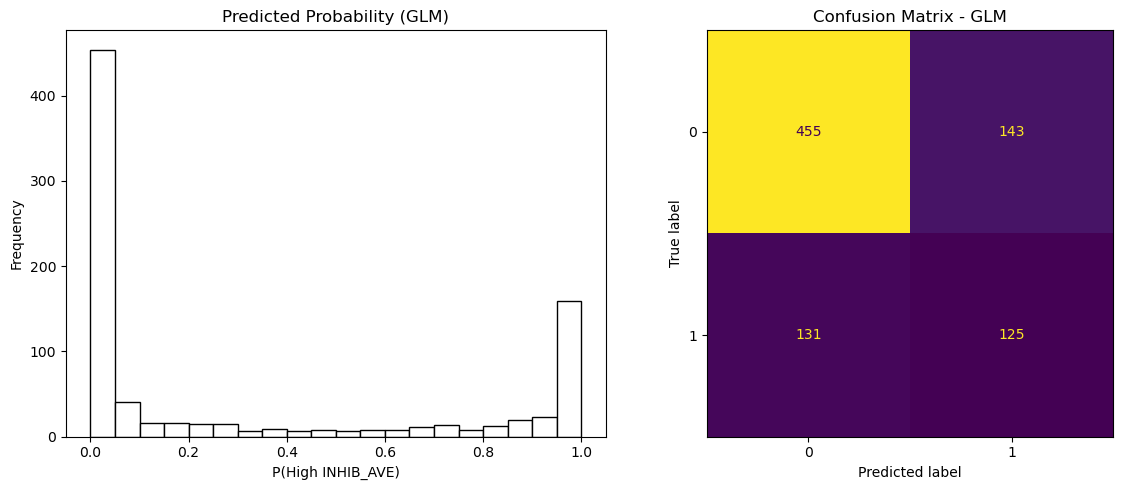

In [25]:
X_test_glm = sm.add_constant(X_test_scaled, has_constant='add')

y_prob_log = glm_results.predict(X_test_glm)
y_pred_log = (y_prob_log > 0.5).astype(int)
print("Accuracy:", accuracy_score(ydummy_test, y_pred_log))

coefficients = pd.DataFrame({"Feature": X_train_scaled.columns, "Coef": glm_results.params[1:]})

coefficients["Odds Ratio"] = np.exp(coefficients["Coef"])

print(coefficients.sort_values("Odds Ratio", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Probability histogram
axes[0].hist(y_prob_log, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability (GLM)")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")


# Confusion matrix
cm = confusion_matrix(ydummy_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM")

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report
print(classification_report(ydummy_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       598
           1       0.47      0.49      0.48       256

    accuracy                           0.68       854
   macro avg       0.62      0.62      0.62       854
weighted avg       0.68      0.68      0.68       854



While the GLM achieved an overall accuracy of 0.80, performance was strongly imbalanced across classes. The model showed high recall for low-inhibition compounds (0.97), but substantially lower recall for high-inhibition compounds (0.35), indicating a conservative prediction bias. This suggests that the model prioritizes specificity over sensitivity, leading to a significant number of false negatives among biologically active compounds. As a result, accuracy alone is not sufficient to evaluate model performance in this context, and metrics such as a confusion matrix and recall provide a more informative assessment.

-------------
## Logistic Regression with Feature Selection

Several predictors exhibited high p-values, suggesting redundancy and multicollinearity among molecular descriptors. While PCA could reduce dimensionality, it would compromise interpretability. Therefore, feature selection or more flexible nonlinear models may be more appropriate for capturing the structure–activity relationships present in the dataset.

In [27]:
selected_features = [
    "DMAX_AVE",
    "HBD",
    "HBA",
    "ArRings",
    "MIC_VALUE_uM",
    "INHIB_STD",
    "RotBonds",
    "Rings"
]

X_train_sel = sm.add_constant(X_train_scaled[selected_features])
X_test_sel = sm.add_constant(X_test_scaled[selected_features])

glm_sel = sm.GLM(ydummy_train, X_train_sel, family=sm.families.Binomial())
glm_sel_results = glm_sel.fit()

print(glm_sel_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              INHIB_AVE   No. Observations:                 3414
Model:                            GLM   Df Residuals:                     3405
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1760.7
Date:                Tue, 05 May 2026   Deviance:                       3521.4
Time:                        01:29:21   Pearson chi2:                 3.59e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1728
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.8989      0.042    -21.251   

Accuracy: 0.7716627634660421


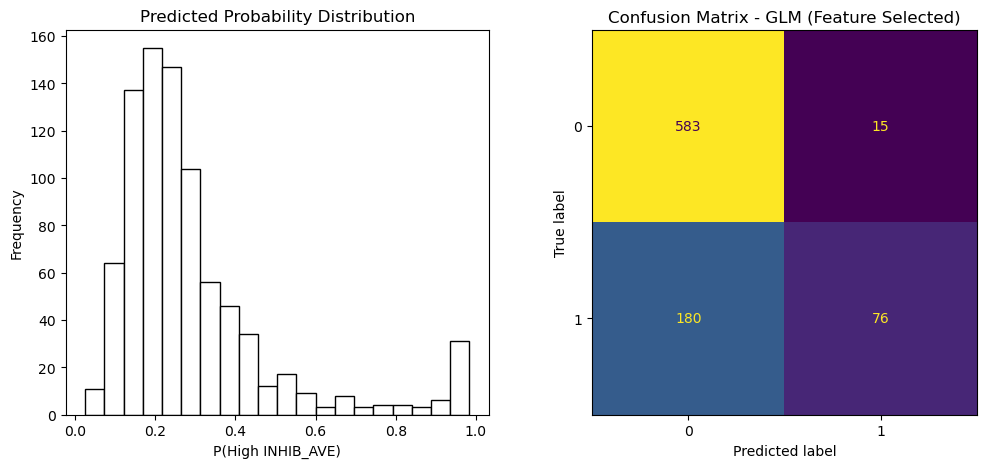


Report:
               precision    recall  f1-score   support

           0       0.76      0.97      0.86       598
           1       0.84      0.30      0.44       256

    accuracy                           0.77       854
   macro avg       0.80      0.64      0.65       854
weighted avg       0.79      0.77      0.73       854



In [28]:
y_prob_sel = glm_sel_results.predict(X_test_sel)
y_pred_sel = (y_prob_sel > 0.5).astype(int)

print("Accuracy:", accuracy_score(ydummy_test, y_pred_sel))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(ydummy_test, y_pred_sel)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix - GLM (Feature Selected)")

axes[0].hist(y_prob_sel, bins=20, edgecolor='black', color='white')
axes[0].set_title("Predicted Probability Distribution")
axes[0].set_xlabel("P(High INHIB_AVE)")
axes[0].set_ylabel("Frequency")

plt.show()

print("\nReport:\n", classification_report(ydummy_test, y_pred_sel))

The limitations observed in the GLM suggest that the relationship between molecular descriptors and antibacterial activity is nonlinear. This motivates the use of nonlinear classifiers such as Support Vector Machines and tree-based ensemble methods, which can better capture complex decision boundaries in the feature space.

## Model 3: Simple Artificial Neural Network (ANN)

As our third model we are using Multi-Layer Perceptron Classifier (MLPClassifier)
This is a simpple feedforward neural network with one hidden layer that learns non-linear relationships between molecular descriptors and antibacterial activity. 

In [29]:
# Creating separate binary labels for ANN using top 10% threshold
# Keeping top 30% for other models, trying top 10% here to see if it improves results
ydummy_train_ann = (y_train > y_train.quantile(0.9)).astype(int)
ydummy_test_ann = (y_test > y_test.quantile(0.9)).astype(int)

# Sanity check, verify class balance with top 10% threshold
print("ANN Training class balance:", ydummy_train_ann.value_counts())
print("ANN Test class balance:", ydummy_test_ann.value_counts())

ANN Training class balance: INHIB_AVE
0    3072
1     342
Name: count, dtype: int64
ANN Test class balance: INHIB_AVE
0    768
1     86
Name: count, dtype: int64


Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3949 - val_loss: 0.3097
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 0.1124 - val_loss: 0.3011
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 0.0641 - val_loss: 0.3260
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.0543 - val_loss: 0.3181
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - loss: 0.0422 - val_loss: 0.3325
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 0.0304 - val_loss: 0.3622
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.0312 - val_loss: 0.3662
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - loss: 0.0249 - val_loss: 0.3633
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - loss: 0.0212 - val_loss: 0.3705
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - loss: 0.0236 - val_loss: 0.3610
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0234 - val_loss: 0.3606
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

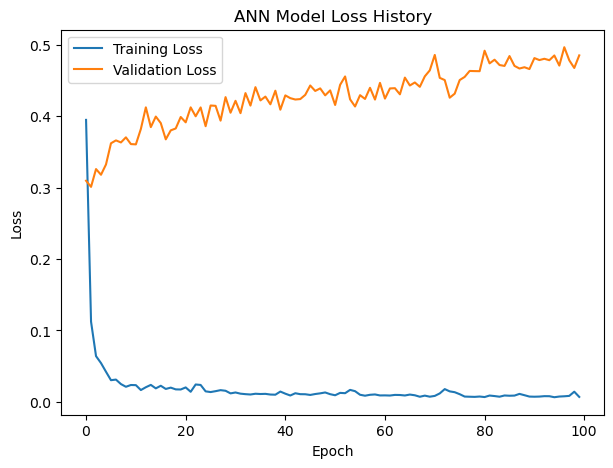

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step
Accuracy: 0.9332552693208431
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       768
           1       0.74      0.52      0.61        86

    accuracy                           0.93       854
   macro avg       0.84      0.75      0.79       854
weighted avg       0.93      0.93      0.93       854



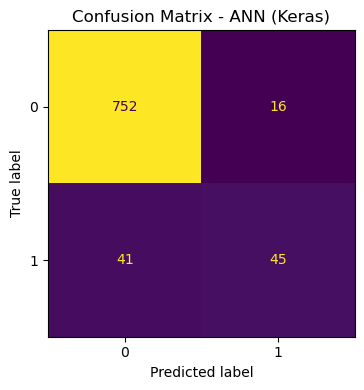

In [30]:
# Number of classes - we have 2 (active and inactive)
NClasses = 2

# One-hot encode the binary labels for Keras, using lines from keras notebook from lecture 15
Y_train_oh = keras.utils.to_categorical(ydummy_train_ann, NClasses)
Y_test_oh = keras.utils.to_categorical(ydummy_test_ann, NClasses)
# Number of neurons in the hidden layer
Nneuron = 64

# Building the ANN model using My_Keras_Model function pattern
def My_Keras_Model(Nneuron, NClasses):
    return keras.Sequential([
        # To help with the overfitting adding more dropout
        layers.Dense(Nneuron,  activation='relu'),
        layers.Dense(NClasses, activation='softmax')
    ])
keras_model = My_Keras_Model(Nneuron, NClasses)

# Compiling the model with adam optimizer and categorical_crossentropy loss
keras_model.compile(optimizer='adam', loss='categorical_crossentropy')

# Number of training epochs
Nepochs = 100

# Training the model on scaled training data with validation_split=0.2
history = keras_model.fit(X_train_scaled, Y_train_oh, epochs=Nepochs, validation_split=0.2)

# Plot the training and validation loss history
fig, ax = plt.subplots(figsize=(7,5))

# plot history['loss'] and history['val_loss']
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')

ax.set_title('ANN Model Loss History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Make predictions on test data
P = keras_model.predict(X_test_scaled)

# Convert probabilities to class labels using np.argmax
y_pred_ann = np.argmax(P, axis=1)

# Printing the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann))

# Printing the classification report
print(classification_report(ydummy_test_ann, y_pred_ann))

# Ploting the confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(ydummy_test_ann, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - ANN (Keras)')
plt.tight_layout()
plt.show()

Using a top 10% inhibition threshold for the ANN improved accuracy to 93%.The model still shows some overfitting with validation loss diverging from training loss likely due to the class imbalance with only 10% active compounds. Despite this, the higher accuracy and improved F1 score suggest the top 10% threshold produces a more learnable classification boundary.

## Clustering Analysis
Applying K-Means clustering to explore 
whether active and inactive compounds naturally separate in the feature space.

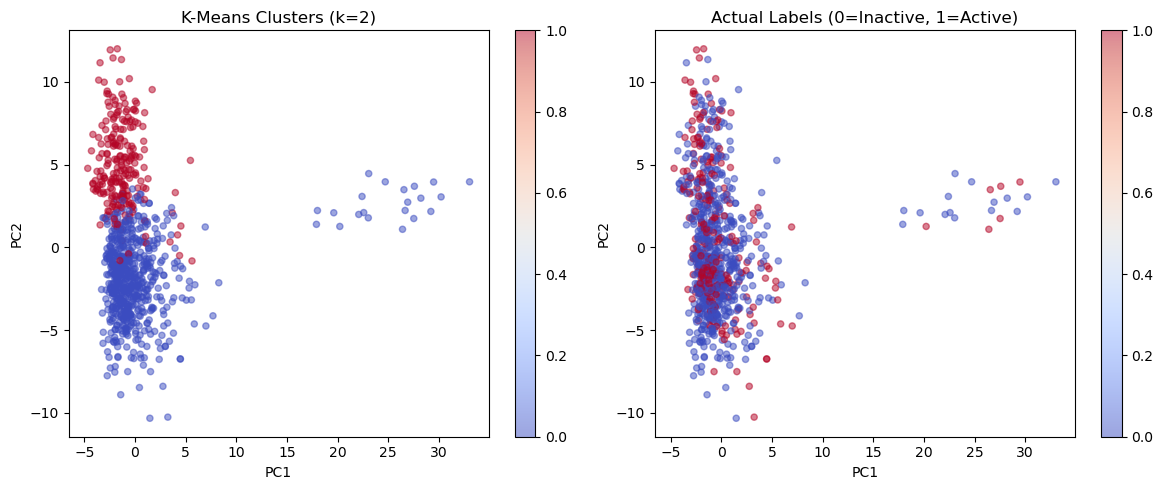

Cluster counts: 0    623
1    231
Name: count, dtype: int64


In [31]:
# Create KMeans model with 2 clusters since we have 2 classes (active and inactive)
# Added n_init=10 and max_iter=300 to improve clustering. Initial run with defaults resulted in a 853:1 split which was not meaningful
kmeans = KMeans(n_clusters=2, random_state=28, n_init=10, max_iter=300)

# Fit the model on the scaled training data
kmeans.fit(X_train_scaled)

# Get cluster labels for the test data
cluster_labels = kmeans.predict(X_test_scaled)

# Reduce to 2D using PCA so we can visualize the clusters
pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X_test_scaled)

# Plotting the clusters vs actual labels side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - color points by cluster label
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.5, s=20)
axes[0].set_title('K-Means Clusters (k=2)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# Plotting the 2 color points by actual active/inactive labels
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=ydummy_test, cmap='coolwarm', alpha=0.5, s=20)
axes[1].set_title('Actual Labels (0=Inactive, 1=Active)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

# Print how many compounds fell into each cluster
print("Cluster counts:", pd.Series(cluster_labels).value_counts())

Running K-Means clustering with k=2 to see if the compounds would naturally split into active and inactive groups. Cluster 0 had 623 compounds and Cluster 1 had 231 compounds which is pretty close to our 70/30 class split. When we compare the clusters to our actual labels though, they don't line up perfectly the molecular descriptors alone aren't enough to cleanly separate active from inactive 
compounds. This makes sense given that our models also struggled with recall on the active class.

## UMAP

We use UMAP (Uniform Manifold Approximation and Projection) to visualize our high dimensional data in 2D. This helps us see if active and inactive compounds naturally separate in the feature space. 

/Users/priscillavaskez/opt/miniconda3/envs/chem277a-ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


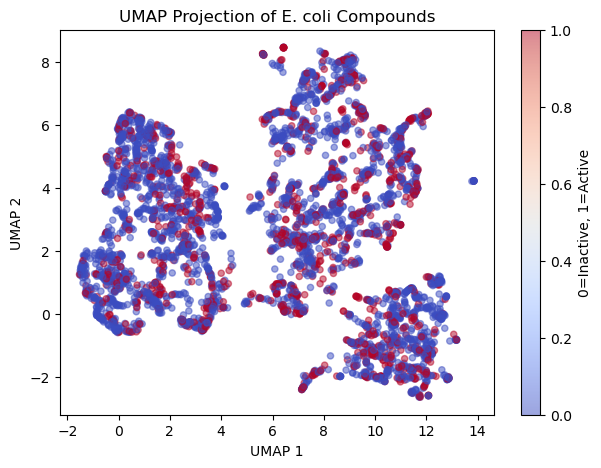

In [32]:
# Use only the original molecular descriptors for UMAP visualization
DESCRIPTOR_COLUMNS = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED']

# Scale just these columns
scaler_umap = StandardScaler()
X_umap_features = scaler_umap.fit_transform(master_df[DESCRIPTOR_COLUMNS])

# Create UMAP reducer
reducer = umap.UMAP(n_components=2, random_state=28)

# Fit and transform
X_umap = reducer.fit_transform(X_umap_features)

# Get labels for all data
y_all = (master_df['INHIB_AVE'] > master_df['INHIB_AVE'].quantile(0.7)).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(7,5))
scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y_all, cmap='coolwarm', alpha=0.5, s=20)
ax.set_title('UMAP Projection of E. coli Compounds')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=ax, label='0=Inactive, 1=Active')
plt.show()

Looking at the UMAP projection, most compounds are clumped together in one big dense cluster with active and inactive compounds all mixed in together. There is no real separation between the two classes which makes sense given that our models had a hard time identifying active compounds too. 